In [1]:
import numpy as np
from estimation import _calculate_statistics, _analyze_threshold_trends
import matplotlib.pyplot as plt
import os



from masking import make_inclusion_mask
from processing import get_maps, prepare_maps
from configuration import get_file_config
from estimation import plot_extrapolation_estimate
from logger import setup_logger
from monster import main_alt, apply_config, apply_config_rsEGFP2

%load_ext autoreload
%autoreload 2

logger = setup_logger()


2026-01-08 15:31:24,709: logger: INFO: Imposing high_resolution_limit: 2.6 (processing.py:37)


0 11_100us/100us
1 9_10us/10us
3 7_30ns/30ns
5 3_300ps/300ps
6 10_30us/30us
7 2_3ps/3ps
8 4_1ns/1ns
10 8_1us/1us
13 6_10ns/10ns
14 5_3ns/3ns
/Users/sbielfel/Nextcloud2/time_resolved/data/photolyase/7_30ns/30ns_deposit.mtz


2026-01-08 15:31:26,693: logger: INFO: this is calculate_again True (processing.py:88)
2026-01-08 15:31:26,695: logger: INFO: loading: 0.07, tv_weight: 0.005807665501203384, only_kweighted: False (processing.py:109)


2026-01-08 15:31:27 [info     ] scaling: native --> calculated weight_using_uncertainties=True
2026-01-08 15:31:27 [info     ] scaling: derivative --> calculated weight_using_uncertainties=True
2026-01-08 15:31:27 [info     ] Computing difference map.     
2026-01-08 15:31:27 [info     ]   using fixed                  kparameter=0.07
2026-01-08 15:31:27 [info     ] TV denoising with fixed weight weight=0.005807665501203384
2026-01-08 15:31:30 [info     ] Map TV-denoised with fixed weight final_negentropy=2.94e-01 initial_negentropy=9.97e-03 weight=0.005807665501203384


2026-01-08 15:31:30,136: logger: INFO: diffmap has uncertainties: True (processing.py:151)
2026-01-08 15:31:30,163: logger: INFO: Diffmap std: 0.001 (processing.py:260)
2026-01-08 15:31:30,164: logger: INFO: diffmap larger voxel count: 0.15520061728395063 (processing.py:261)
2026-01-08 15:31:30,231: logger: INFO: ignore_mask voxel count: 0.5746728395061729 (processing.py:205)
2026-01-08 15:31:30,241: logger: INFO: Shift value 0.31973 corresponds to zero frequency 450570.750 (processing.py:219)
2026-01-08 15:31:30,268: logger: INFO: calculating autoshift for triggered map... with extra mask (processing.py:270)
2026-01-08 15:31:30,331: logger: INFO: ignore_mask voxel count: 0.6968371913580247 (processing.py:205)
2026-01-08 15:31:30,342: logger: INFO: Shift value 0.31680 corresponds to zero frequency 446447.781 (processing.py:219)
2026-01-08 15:31:30,373: logger: INFO: calculating autoshift for triggered map... done (processing.py:274)
2026-01-08 15:31:30,373: logger: INFO: this is calcul

2026-01-08 15:31:30 [info     ] scaling: native --> calculated weight_using_uncertainties=True
2026-01-08 15:31:31 [info     ] scaling: derivative --> calculated weight_using_uncertainties=True
2026-01-08 15:31:31 [info     ] Computing difference map.     
2026-01-08 15:31:31 [info     ]   using fixed                  kparameter=0.07
2026-01-08 15:31:31 [info     ] TV denoising with fixed weight weight=0.005807665501203384
2026-01-08 15:31:33 [info     ] Map TV-denoised with fixed weight final_negentropy=1.55e-01 initial_negentropy=5.26e-03 weight=0.005807665501203384


2026-01-08 15:31:33,854: logger: INFO: diffmap has uncertainties: True (processing.py:151)
2026-01-08 15:31:33,855: logger: INFO: Diffmap zero frequency: 0.04890799522399902 (processing.py:286)
2026-01-08 15:31:33,879: logger: WARNING: Diffmap Mean: 0.000000, Std: 0.002975 (1705048879.py:9)
2026-01-08 15:31:33,918: logger: WARNING: Used threshold for posmask: 0.134, found 1921 blobs (masking.py:131)
2026-01-08 15:31:33,924: logger: INFO: Using blobs with more than 5.517894359740814(3 A^3) voxels (masking.py:146)
2026-01-08 15:31:33,924: logger: INFO: Maximum Blob sizes found: 411 (masking.py:147)
2026-01-08 15:31:34,158: logger: INFO: Applying blocking radius of 1.5 A around positive density regions creating a mask of shape (5, 5, 5), considering a total of 26 voxels (control via 'blocking_radius' parameter) (masking.py:179)
2026-01-08 15:31:34,249: logger: INFO: Excluding 3 (0.02%) voxels from mask due to positive density within 1.5 A and above the 99 percentile (control via 'blocking

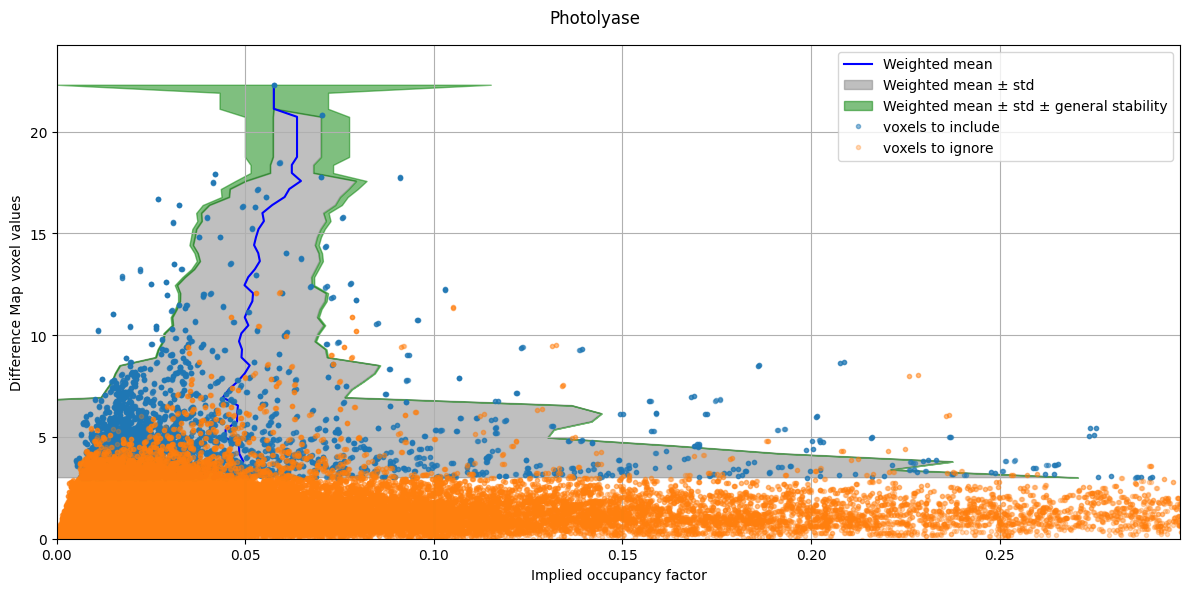

In [ ]:


config = apply_config()
config["map_processing"]["diffmap_mean_correction"] = False
config["map_processing"]["dark_mean_correction"] = True
config["map_processing"]["diffmap_v2_correction"] = False
unscaled_dark, unscaled_triggered = get_maps(config)
diffmap, map_dark, _ = prepare_maps(unscaled_dark, unscaled_triggered, config)

diffmap_np = diffmap.to_3d_numpy_map(map_sampling=config["general"]["map_sampling"])
logger.warning(f"Diffmap Mean: {diffmap_np.mean():.6f}, Std: {diffmap_np.std():.6f}")
inclusion_mask = make_inclusion_mask(diffmap, map_dark, config)
# diffmap_np, map_dark_np = _prepare_maps(
#     diffmap, map_dark, map_dark_comp, info_container, params
# )
fig, ax = plot_extrapolation_estimate(diffmap, map_dark, inclusion_mask, config)
fig.savefig("../tex2/figs/rsEGFP2_tv.png")
plt.show()




2026-01-08 15:38:08,917: logger: INFO: Imposing high_resolution_limit: 1.6 (processing.py:37)
2026-01-08 15:38:11,409: logger: INFO: this is calculate_again True (processing.py:88)
2026-01-08 15:38:11,410: logger: INFO: loading: 0.17, tv_weight: 0.007515095428704186, only_kweighted: False (processing.py:109)


2026-01-08 15:38:11 [info     ] scaling: native --> calculated weight_using_uncertainties=True
2026-01-08 15:38:12 [info     ] scaling: derivative --> calculated weight_using_uncertainties=True
2026-01-08 15:38:12 [info     ] Computing difference map.     
2026-01-08 15:38:12 [info     ]   using fixed                  kparameter=0.17
2026-01-08 15:38:12 [info     ] TV denoising with fixed weight weight=0.007515095428704186
2026-01-08 15:38:13 [info     ] Map TV-denoised with fixed weight final_negentropy=7.35e-02 initial_negentropy=-9.35e-05 weight=0.007515095428704186


2026-01-08 15:38:13,816: logger: INFO: diffmap has uncertainties: True (processing.py:151)
2026-01-08 15:38:13,835: logger: INFO: Diffmap std: 0.002 (processing.py:260)
2026-01-08 15:38:13,842: logger: INFO: diffmap larger voxel count: 0.24967997685185186 (processing.py:261)
2026-01-08 15:38:13,943: logger: INFO: ignore_mask voxel count: 0.4218263888888889 (processing.py:205)
2026-01-08 15:38:13,949: logger: INFO: Shift value 0.32986 corresponds to zero frequency 77710.844 (processing.py:219)
2026-01-08 15:38:13,972: logger: INFO: calculating autoshift for triggered map... with extra mask (processing.py:270)
2026-01-08 15:38:14,021: logger: INFO: ignore_mask voxel count: 0.5675798611111111 (processing.py:205)
2026-01-08 15:38:14,030: logger: INFO: Shift value 0.32889 corresponds to zero frequency 77482.227 (processing.py:219)
2026-01-08 15:38:14,050: logger: INFO: calculating autoshift for triggered map... done (processing.py:274)
2026-01-08 15:38:14,051: logger: INFO: this is calculat

2026-01-08 15:38:14 [info     ] scaling: native --> calculated weight_using_uncertainties=True
2026-01-08 15:38:14 [info     ] scaling: derivative --> calculated weight_using_uncertainties=True
2026-01-08 15:38:14 [info     ] Computing difference map.     
2026-01-08 15:38:14 [info     ]   using fixed                  kparameter=0.17
2026-01-08 15:38:14 [info     ] TV denoising with fixed weight weight=0.007515095428704186
2026-01-08 15:38:16 [info     ] Map TV-denoised with fixed weight final_negentropy=2.02e-02 initial_negentropy=1.60e-04 weight=0.007515095428704186


2026-01-08 15:38:16,446: logger: INFO: diffmap has uncertainties: True (processing.py:151)
2026-01-08 15:38:16,447: logger: INFO: Diffmap zero frequency: 0.005540370941162109 (processing.py:286)
2026-01-08 15:38:16,467: logger: WARNING: Diffmap Mean: -0.000000, Std: 0.006007 (3175241889.py:10)
2026-01-08 15:38:16,496: logger: WARNING: Used threshold for posmask: 0.399, found 1445 blobs (masking.py:131)
2026-01-08 15:38:16,500: logger: INFO: Using blobs with more than 22.00452891919375(3 A^3) voxels (masking.py:146)
2026-01-08 15:38:16,500: logger: INFO: Maximum Blob sizes found: 64 (masking.py:147)
2026-01-08 15:38:16,521: logger: INFO: Applying blocking radius of 1.5 A around positive density regions creating a mask of shape (7, 7, 7), considering a total of 92 voxels (control via 'blocking_radius' parameter) (masking.py:178)
2026-01-08 15:38:16,666: logger: INFO: Excluding 0 (0.00%) voxels from mask due to positive density within 1.5 A and above the 99 percentile (control via 'blocki

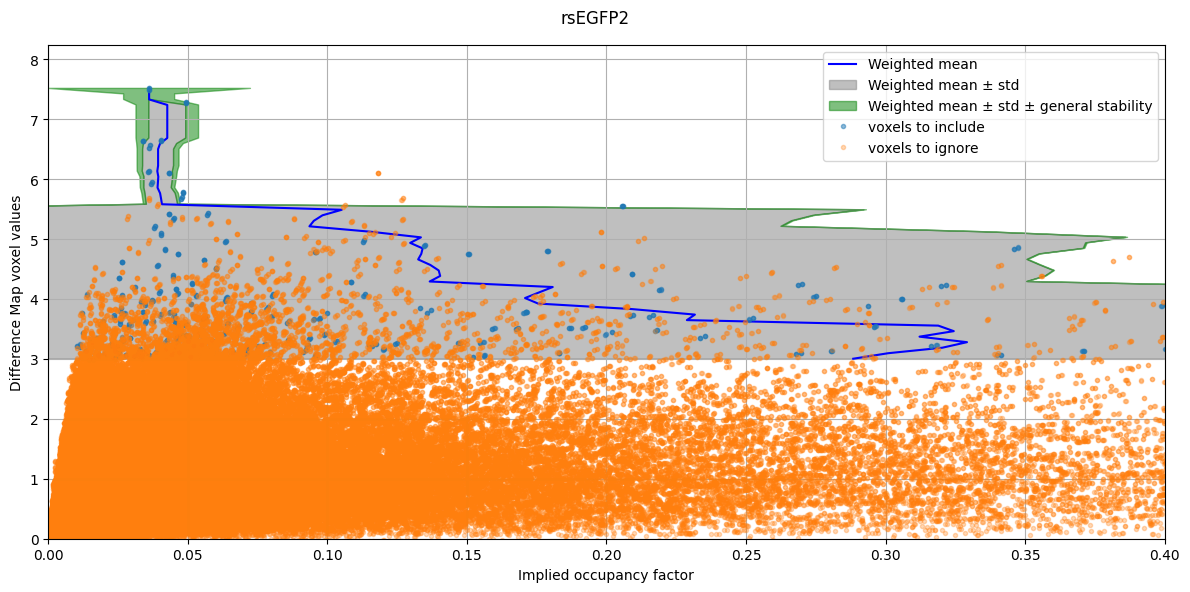

In [3]:
config = apply_config_rsEGFP2()
config["map_processing"]["diffmap_mean_correction"] = False
config["map_processing"]["dark_mean_correction"] = True
config["map_processing"]["diffmap_v2_correction"] = False
config["masking"]["blocking_percentile"] = 99
unscaled_dark, unscaled_triggered = get_maps(config)
diffmap, map_dark, _ = prepare_maps(unscaled_dark, unscaled_triggered, config)

diffmap_np = diffmap.to_3d_numpy_map(map_sampling=config["general"]["map_sampling"])
logger.warning(f"Diffmap Mean: {diffmap_np.mean():.6f}, Std: {diffmap_np.std():.6f}")
inclusion_mask = make_inclusion_mask(diffmap, map_dark, config)
# diffmap_np, map_dark_np = _prepare_maps(
#     diffmap, map_dark, map_dark_comp, info_container, params
# )
fig, ax = plot_extrapolation_estimate(diffmap, map_dark, inclusion_mask, config)
ax.set_xlim(0, 0.4)
plt.show()
fig.savefig("../tex2/figs/rsEGFP2_tv.png")




In [ ]:
config = apply_config_rsEGFP2()
config["map_processing"]["diffmap_mean_correction"] = False
config["map_processing"]["dark_mean_correction"] = True
config["map_processing"]["diffmap_v2_correction"] = False
config["map_processing"][""] = False
config["masking"]["blocking_percentile"] = 99
unscaled_dark, unscaled_triggered = get_maps(config)
diffmap, map_dark, _ = prepare_maps(unscaled_dark, unscaled_triggered, config)

diffmap_np = diffmap.to_3d_numpy_map(map_sampling=config["general"]["map_sampling"])
logger.warning(f"Diffmap Mean: {diffmap_np.mean():.6f}, Std: {diffmap_np.std():.6f}")
inclusion_mask = make_inclusion_mask(diffmap, map_dark, config)
# diffmap_np, map_dark_np = _prepare_maps(
#     diffmap, map_dark, map_dark_comp, info_container, params
# )
fig, ax = plot_extrapolation_estimate(diffmap, map_dark, inclusion_mask, config)
ax.set_xlim(0, 0.4)
plt.show()
fig.savefig("../tex2/figs/rsEGFP2_tv.png")



